# Visualization: Session 3 (January 27, 2026)

Topics for Session 5: 

Slide Deck 8: Visualization with Purpose - Data Visualization as Advocacy
- Explore examples and ideas behind data visualization as used for advocacy
- Discuss how, through form, representation, and credit, we can put advocacy into practice with our own data visualizations

Slide Deck 9: Beyond Matplotlib
- Learn about other packages to use for data visualization in Python, such as:
- Seaborn
- Plotly (for interactive viz)
- Wordclouds and Venn Diagrams
- Discuss when to use (and when not to use) interactive data visualization

# Seaborn
-  A data viz package built on top of matplotlib
- REALLY SIMILAR to matplotlib (phew!) but takes care of some semantic mapping for us
- Recall: mapping is deciding which aspects of our dataset correspond to which visual elements on our plots

In [25]:
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import scipy
import PIL
import requests

     total_bill   tip     sex smoker   day    time  size
0         16.99  1.01  Female     No   Sun  Dinner     2
1         10.34  1.66    Male     No   Sun  Dinner     3
2         21.01  3.50    Male     No   Sun  Dinner     3
3         23.68  3.31    Male     No   Sun  Dinner     2
4         24.59  3.61  Female     No   Sun  Dinner     4
..          ...   ...     ...    ...   ...     ...   ...
239       29.03  5.92    Male     No   Sat  Dinner     3
240       27.18  2.00  Female    Yes   Sat  Dinner     2
241       22.67  2.00    Male    Yes   Sat  Dinner     2
242       17.82  1.75    Male     No   Sat  Dinner     2
243       18.78  3.00  Female     No  Thur  Dinner     2

[244 rows x 7 columns]


[Text(0.5, 1.0, 'Tips vs. Total Bill'),
 Text(0.5, 0, 'Total Bill ($)'),
 Text(0, 0.5, 'Tip Amount ($)')]

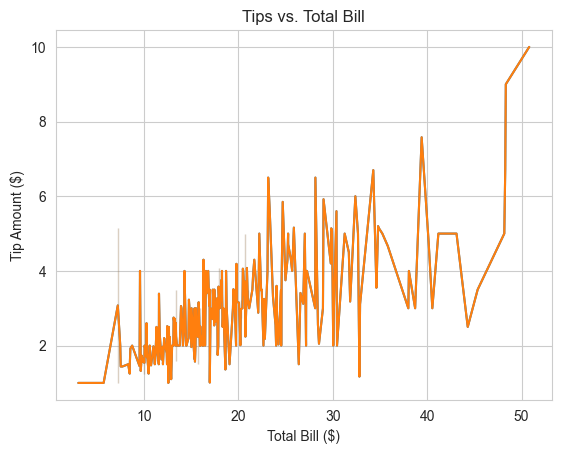

In [26]:
# load data 
tips = sns.load_dataset("tips")
print(tips)

# basic plot 
sns.lineplot(data=tips, # choose our dataset
x='total_bill', # define our x variable
y='tip') # define our y variable

#use premade styles

sns.set_style('whitegrid')

# add axis and title
tipgraph = sns.lineplot(data=tips,
x='total_bill',
y='tip')
tipgraph.set(title='Tips vs. Total Bill',
xlabel='Total Bill ($)',
ylabel='Tip Amount ($)')

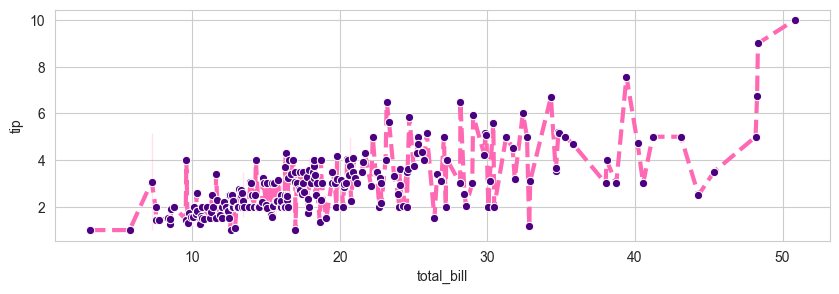

In [27]:
# modify 
fig = plt.subplots(figsize=(10, 3))
tipgraph = sns.lineplot(data=tips,
x='total_bill',
y='tip',
color = 'hotpink',
linestyle = '--',
linewidth = 3,
marker = 'o',
markerfacecolor = 'indigo')

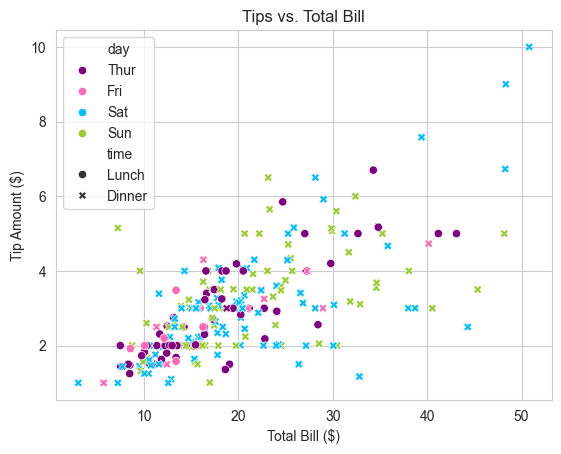

In [28]:
# Add multiple variables
# Seaborn makes it very easy to represent multiple variables
# with different visual elements of our graph

tipgraph = sns.scatterplot(
    data=tips,
    x='total_bill',
    y='tip',
    style='time',
    hue='day',
    palette=['purple', 'hotpink', 'deepskyblue', 'yellowgreen']
)

tipgraph.set(
    title='Tips vs. Total Bill',
    xlabel='Total Bill ($)',
    ylabel='Tip Amount ($)'
)

plt.show()


# Pairplot
- Pairplot is another convenient way to compare variables

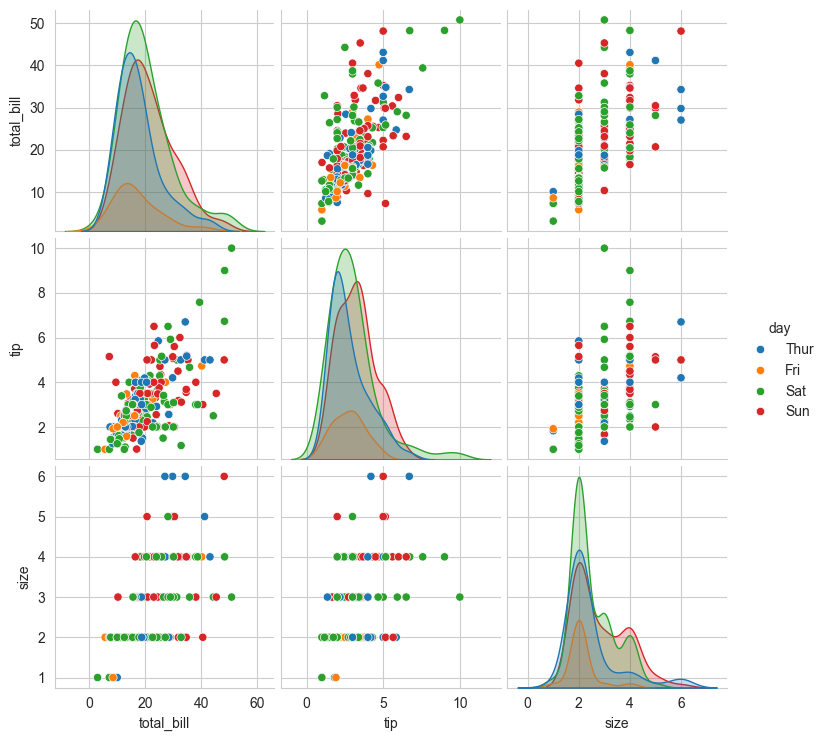

In [29]:
sns.pairplot(
data = tips,
hue = 'day')

# Relplot
relplot also lets us explore specific levels within variables

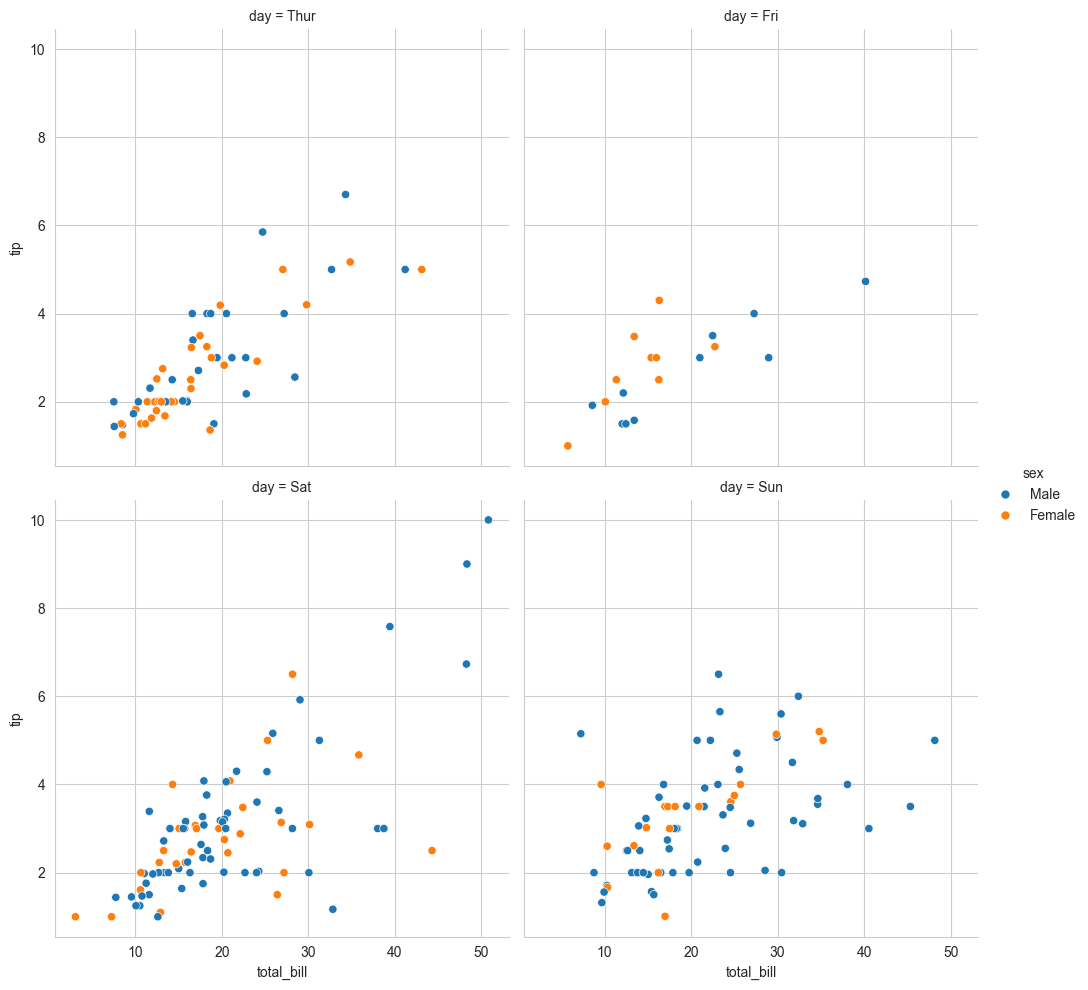

In [30]:
daysplot = sns.relplot(
data=tips,
x="total_bill",
y="tip",
hue="sex",
col="day",
kind="scatter",
col_wrap=2)

# Activity:
Comment this snippet of code and describe what each new element is doing

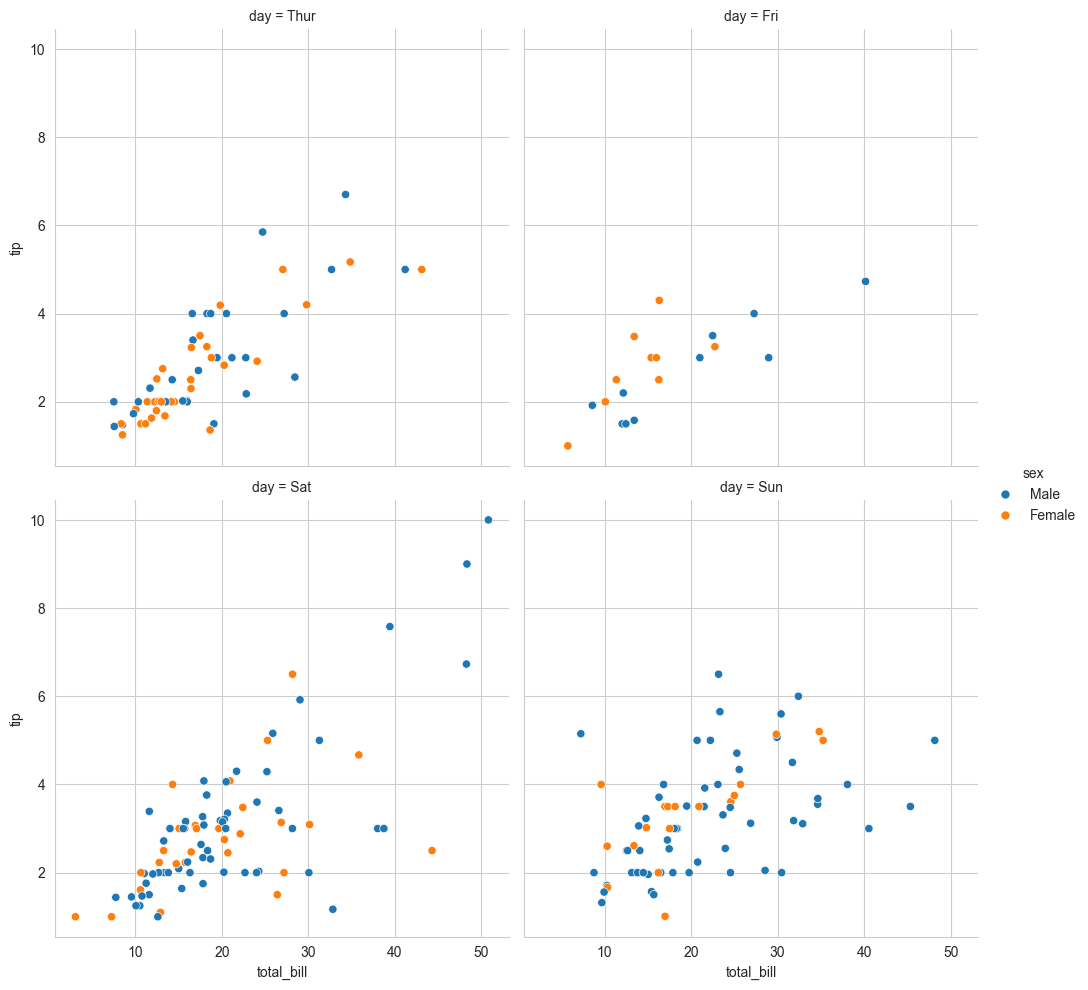

In [31]:
# Create a relational plot of tips data
daysplot = sns.relplot(
    data=tips,           # The dataset we are visualizing (a Pandas DataFrame)
    x="total_bill",      # Column in 'tips' for the x-axis
    y="tip",             # Column in 'tips' for the y-axis
    hue="sex",           # Variable that defines the color of the points (different colors for different sexes)
    col="day",           # Variable that defines separate plots (facets) for each day
    kind="scatter",      # Type of plot: scatterplot (points plotted for x vs y)
    col_wrap=2           # Wrap the facet columns after 2 plots per row (controls layout when there are many days)
)


# Case Study: Gender bias in teaching evaluations

How does faculty gender impact course evaluations?
- The gender of instructors ( perceived or actual ) influences how they are scored by students on teaching and course evaluations, with student evaluations tending to be significantly biased in favour of men and against women, even when all else is equal
- The bias in these student evaluations can adversely impact the ability of female scholars to be “full-time tenure-track, to hold tenured positions, to attain higher leadership roles in academia, and to earn the same salary as males in the same positions”

Activity: Comparing data visualizations

Left: Shows the mean student ratings for instructors by actual and perceived gender. Simple numeric comparison using vertical bars.

Right: Displays the frequency of words used to describe male vs. female professors across millions of reviews. Allows exploration by search term, rating type (all/positive/negative), and gender.

# Static vs. dynamic data visualization
Static data visualization
 - An image-based chart or infographic (think PDF, PNG, JPG)
 - A snapshot of data
 - Most of what we have seen so far in this course
 
 Dynamic data visualization
- Interactive applications or web pages that allow users to modify or filter a data visualization
- Multiple data stories in one

# Activity: Types of changes

Data subset, Filtering by:
- Gender (male/female professors)
- Rating type (all, positive, negative)
- Department or course
- Specific search term(s)
Position of points: Words may shift horizontally/vertically depending on their relative frequency after filtering.
Color or hue: May update to highlight the selected gender or category.
Size or opacity of markers – If word frequency is represented by size, markers may grow or shrink dynamically.

# Plotly

In [32]:
%pip install plotly

import plotly.graph_objects as go
import numpy as np


[notice] A new release of pip is available: 24.2 -> 26.0
[notice] To update, run: pip3 install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [33]:
x1 = np.array(["Luffy", "Zoro", "Nami", "Usopp", "Sanji"])
y1 = np.array([110, 180, 240, 99, 220])

# Example: simple bar chart
fig = go.Figure(data=go.Bar(x=x1, y=y1))
fig.show()

#Note: Plotly syntax is different from matplotlib/seaborn
#make our figure
graph = go.Figure()

# choose our plot type (bar) and our data
graph.add_trace(go.Bar(x=x1, y=y1))

#making the plot
graph.update_layout(
title="Pirate Scores",
xaxis_title="Pirates",
yaxis_title="Score")
graph.show()

# Creating Word Clouds


[notice] A new release of pip is available: 24.2 -> 26.0
[notice] To update, run: pip3 install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


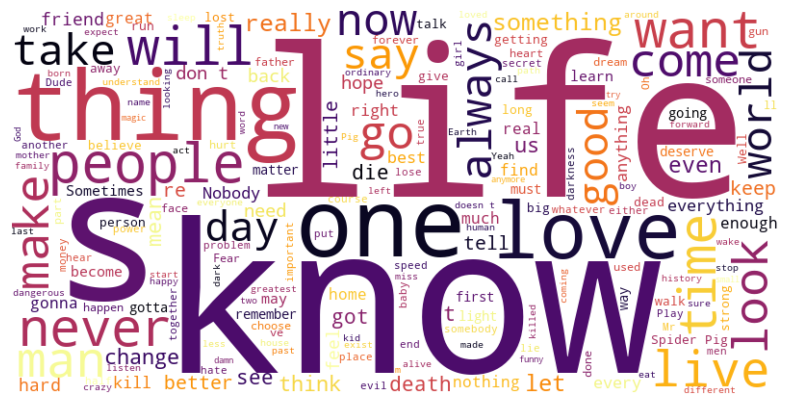

In [38]:
# Install wordcloud (only in Jupyter notebooks)
%pip install wordcloud

# --- Imports ---
import pandas as pd
import matplotlib.pyplot as plt
from wordcloud import WordCloud

# --- Load data ---
df = pd.read_csv(
    "https://raw.githubusercontent.com/prasertcbs/basic-dataset/master/movie_quotes.csv",
    on_bad_lines='skip'
)

# --- Combine all quotes into a single string ---
text = " ".join(each for each in df.quote)

# --- Generate the word cloud ---
wordcloud = WordCloud(
    background_color="white",  # White background
    colormap='inferno',        # Color scheme
    width=800,                 # Width of the image
    height=400                 # Height of the image
).generate(text)

# --- Display the word cloud ---
fig, ax = plt.subplots(figsize=(10, 5))
ax.imshow(wordcloud, interpolation='bilinear')  # Smooth display
ax.axis('off')  # Hide axes for cleaner look

plt.show()


# Making venn diagrams

  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Created wheel for matplotlib-venn: filename=matplotlib_venn-1.1.2-py3-none-any.whl size=45387 sha256=f51432711d29a9079578c19e062a84b5468e7efafcd09e0ada598b451cf1a5bb
  Stored in directory: /Users/susannahclinker/Library/Caches/pip/wheels/c2/47/0c/f014c55a1cfd56dce41a1cafd23e3c590652b5e71330cc181c
Successfully built matplotlib-venn

[notice] A new release of pip is available: 24.2 -> 26.0
[notice] To update, run: pip3 install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/matplotlib_venn/_util.py:32: UserWarning:

venn2_unweighted is deprecated. Use venn2 with the appropriate layout_algorithm instead.



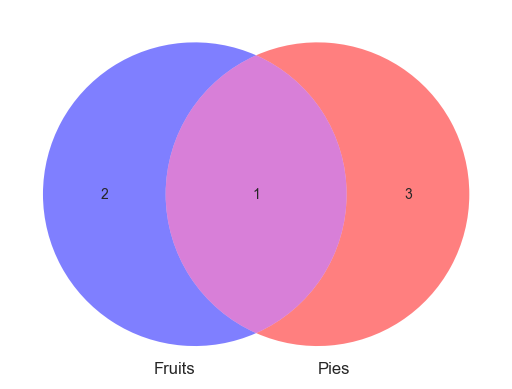

In [41]:
%pip install matplotlib-venn

# Import necessary functions
from matplotlib_venn import venn2, venn2_circles, venn2_unweighted
import matplotlib.pyplot as plt

# Define two sets
A = set(["apple", "banana", "watermelon"])
B = set(["pumpkin", "blueberry", "apple", "key lime"])

# Create an unweighted Venn diagram
diagram = venn2_unweighted(
    [A, B],                       # The two sets
    set_labels=('Fruits', 'Pies'), # Labels for each circle
    set_colors=("blue", "red"),   # Colors of the circles
    alpha=0.5                      # Transparency
)

# Display the diagram
plt.show()


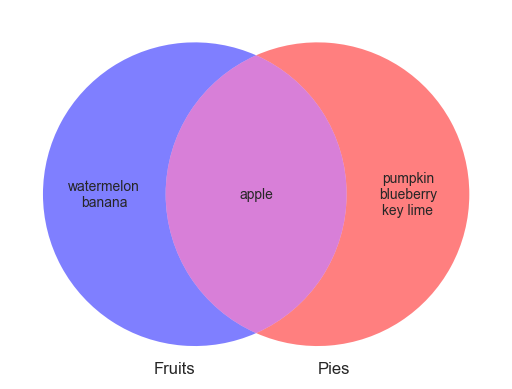

In [47]:
# Define two sets
A = set(["apple", "banana", "watermelon"])
B = set(["pumpkin", "blueberry", "apple", "key lime"])

# Create an unweighted Venn diagram
diagram = venn2_unweighted(
    [A, B],                       # The two sets
    set_labels=('Fruits', 'Pies'), # Labels for each circle
    set_colors=("blue", "red"),   # Colors of the circles
    alpha=0.5                      # Transparency
)

# Set the labels for each subset to show the actual elements
diagram.get_label_by_id("10").set_text("\n".join(A - B))  # Only in A
diagram.get_label_by_id("11").set_text("\n".join(A & B))  # In both A and B
diagram.get_label_by_id("01").set_text("\n".join(B - A))  # Only in B

# Display the diagram
plt.show()
